# BT1 – Phân tích thời gian thực thi chương trình

## Câu 1
Sinh `N` phần tử đầu tiên của dãy Fibonacci bằng:
- Thuật toán đệ quy.
- Thuật toán vòng lặp.

## Câu 2
Đo thời gian chạy khi `N` tăng từ 2 đến 2000 và biểu diễn bằng bảng, đồ thị.

## Câu 3
Dựa trên kết quả thực nghiệm, đánh giá khả năng chạy của hai thuật toán và xác định giới hạn xử lý theo thời gian quy định.

### Thuật toán

Với dãy Fibonacci:

`F(0) = 0`, `F(1) = 1`

`F(n) = F(n-1) + F(n-2)`

- Đệ quy: gọi lại chính hàm Fibonacci để tính từng phần tử.
- Vòng lặp: tính lần lượt từ hai phần tử trước đó.

In [ ]:
%%writefile fibonacci.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <stdexcept>

using namespace std;

const double TIME_LIMIT_MS = 1000.0;
bool timeoutFlag = false;
chrono::high_resolution_clock::time_point startTime;

long long fibRecursive(int n) {
    if (timeoutFlag)
        throw runtime_error("TIMEOUT");

    if (chrono::duration<double, milli>(
            chrono::high_resolution_clock::now() - startTime).count()
        >= TIME_LIMIT_MS) {
        timeoutFlag = true;
        throw runtime_error("TIMEOUT");
    }

    if (n <= 1)
        return n;

    return fibRecursive(n - 1) + fibRecursive(n - 2);
}

double measureRecursive(int n) {
    timeoutFlag = false;
    startTime = chrono::high_resolution_clock::now();

    try {
        volatile long long result = fibRecursive(n);
    } catch (...) {
        return -1.0;
    }

    return chrono::duration<double, milli>(
        chrono::high_resolution_clock::now() - startTime).count();
}

vector<long long> generateFibIterative(int N) {
    if (N <= 0)
        return {};

    if (N == 1)
        return {0};

    vector<long long> result = {0, 1};

    for (int i = 2; i < N; ++i)
        result.push_back(result[i - 1] + result[i - 2]);

    return result;
}

double measureIterative(int N) {
    auto start = chrono::high_resolution_clock::now();

    volatile auto result = generateFibIterative(N);

    return chrono::duration<double, milli>(
        chrono::high_resolution_clock::now() - start).count();
}

int main() {
    const int maxN = 2000;
    bool recursiveStopped = false;

    cout << "N,Iterative_ms,Recursive_ms\n";

    for (int N = 2; N <= maxN; ++N) {
        double iterativeTime = measureIterative(N);
        double recursiveTime = -1.0;

        if (!recursiveStopped) {
            recursiveTime = measureRecursive(N);

            if (recursiveTime < 0.0)
                recursiveStopped = true;
        }

        cout << fixed << setprecision(6)
             << N << ","
             << iterativeTime << ","
             << recursiveTime << "\n";
    }

    return 0;
}


Writing fibonacci.cpp


In [ ]:
!g++ -O0 -std=c++17 fibonacci.cpp -o fibonacci

## Câu 2 – Kết quả đo thực nghiệm

Chương trình được chạy trực tiếp trên Runtime hiện tại của Google Colab. Kết quả gồm 1999 giá trị `N` từ 2 đến 2000.

Thuật toán vòng lặp được đo đầy đủ đến `N = 2000`. Thuật toán đệ quy được đo cho đến khi vượt giới hạn 1 giây; các giá trị `N` còn lại được ghi là `-1` để thể hiện không thực hiện phép đo.

In [ ]:
!./fibonacci > fibonacci_results.csv

In [ ]:
import pandas as pd

df = pd.read_csv("fibonacci_results.csv")

print("Số dòng dữ liệu:", len(df))
print("N nhỏ nhất:", df["N"].min())
print("N lớn nhất:", df["N"].max())

display(df.head(10))
display(df.tail(10))

Số dòng dữ liệu: 1999
N nhỏ nhất: 2
N lớn nhất: 2000


,N,Iterative_ms,Recursive_ms
0,2,0.003062,0.000558
1,3,0.001316,0.000681
2,4,0.001054,0.001086
3,5,0.001151,0.001523
4,6,0.001231,0.002561
5,7,0.001379,0.004233
6,8,0.001352,0.007028
7,9,0.001896,0.011574
8,10,0.001855,0.017221
9,11,0.001833,0.028732


,N,Iterative_ms,Recursive_ms
1989,1991,0.115635,-1.0
1990,1992,0.116502,-1.0
1991,1993,0.111203,-1.0
1992,1994,0.112008,-1.0
1993,1995,0.111013,-1.0
1994,1996,0.110960,-1.0
1995,1997,0.111027,-1.0
1996,1998,0.111212,-1.0
1997,1999,0.116228,-1.0
1998,2000,0.112084,-1.0


## Đồ thị thời gian thực thi

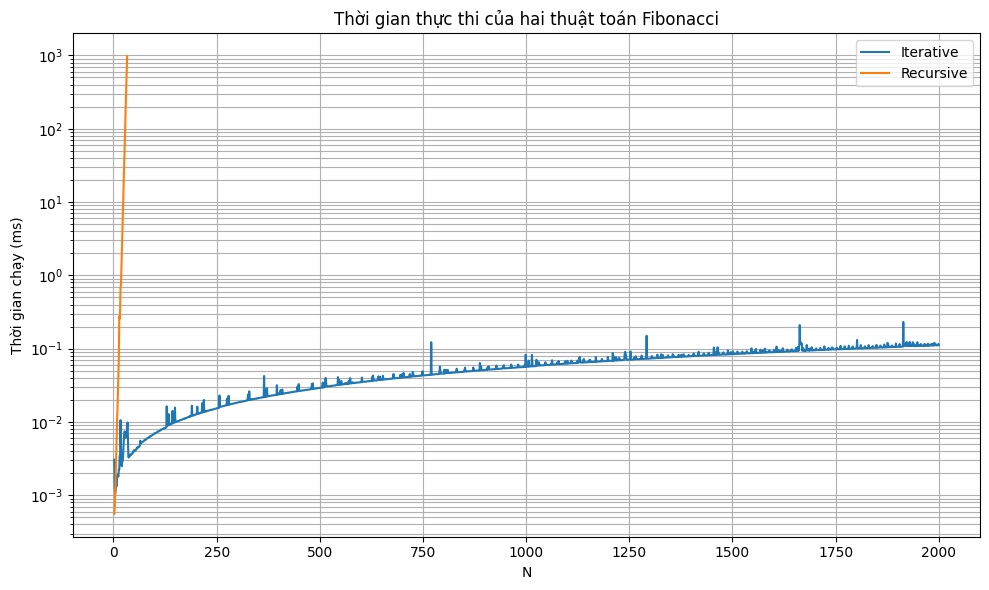

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(df["N"], df["Iterative_ms"], label="Iterative")

recursive = df[df["Recursive_ms"] >= 0]
plt.plot(recursive["N"], recursive["Recursive_ms"], label="Recursive")

plt.yscale("log")
plt.xlabel("N")
plt.ylabel("Thời gian chạy (ms)")
plt.title("Thời gian thực thi của hai thuật toán Fibonacci")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### Nhận xét Câu 2

- Thuật toán vòng lặp có thời gian thực thi tăng chậm khi `N` tăng.
- Thuật toán đệ quy có thời gian thực thi tăng rất nhanh.
- Khi vượt giới hạn thời gian, thuật toán đệ quy được dừng đo; các giá trị còn lại không được gán thời gian giả.
- Đồ thị dùng trục Y logarit để thể hiện rõ sự khác biệt giữa hai thuật toán.

## Câu 3 – Đánh giá khả năng chạy

Để đánh giá định lượng, đặt giới hạn thời gian thực thi là **1 giây**. Nếu đề bài yêu cầu một giới hạn khác, chỉ cần thay giá trị `TIME_LIMIT_MS` bên dưới.

In [ ]:
TIME_LIMIT_MS = 1000

iterative_ok = df[df["Iterative_ms"] <= TIME_LIMIT_MS]
recursive_ok = df[
    (df["Recursive_ms"] >= 0) &
    (df["Recursive_ms"] <= TIME_LIMIT_MS)
]

max_iterative = int(iterative_ok["N"].max()) if not iterative_ok.empty else None
max_recursive = int(recursive_ok["N"].max()) if not recursive_ok.empty else None

print(f"Giới hạn thời gian: {TIME_LIMIT_MS} ms")
print(f"N lớn nhất của Iterative trong giới hạn: {max_iterative}")
print(f"N lớn nhất của Recursive trong giới hạn: {max_recursive}")
print(f"Tổng số giá trị N được xuất: {len(df)}")

Giới hạn thời gian: 1000 ms
N lớn nhất của Iterative trong giới hạn: 2000
N lớn nhất của Recursive trong giới hạn: 33
Tổng số giá trị N được xuất: 1999


### Kết luận

Thuật toán vòng lặp có độ phức tạp thời gian `O(N)`, vì vậy thời gian thực thi tăng tương đối chậm theo `N` và có khả năng xử lý các giá trị `N` lớn hơn.

Thuật toán đệ quy Fibonacci trực tiếp có độ phức tạp thời gian theo cấp số nhân, xấp xỉ `O(2^N)`. Mỗi lần `N` tăng, số lần gọi hàm tăng rất nhanh nên thời gian thực thi tăng mạnh.

Kết quả thực nghiệm cho thấy thuật toán vòng lặp hiệu quả hơn rõ rệt so với thuật toán đệ quy khi `N` lớn. Vì vậy, nếu yêu cầu xử lý số lượng phần tử Fibonacci lớn hoặc phải đáp ứng giới hạn thời gian, nên sử dụng thuật toán vòng lặp.